# Radioactive Decay with Euler Methods

Este notebook resuelve el problema de desintegración radiactiva usando los métodos de Euler explícito e implícito. La ecuación diferencial se basa en el decaimiento exponencial de la cantidad de núcleos:

$$\frac{dN}{dt} = -\alpha N, \quad N(0) = N_0$$

donde $N(t)$ es el número de núcleos activos en el tiempo $t$ y $\alpha$ es la constante de decaimiento. La solución analítica es:

$$N(t) = N_0 e^{-\alpha t}. $$

Se compara la solución exacta con las aproximaciones numéricas de Euler explícito e implícito y se analiza el error y la convergencia.


## Métodos numéricos implementados

- **Euler explícito**: usa la pendiente conocida en el inicio del intervalo para avanzar una aproximación:

$$N_{n+1} = N_n - \alpha \Delta t N_n.$$

- **Euler implícito**: utiliza la pendiente en el punto final del paso, lo que da una fórmula estable para este problema:

$$N_{n+1} = \frac{N_n}{1 + \alpha \Delta t}. $$

El método implícito es más robusto para pasos grandes, mientras que el método explícito es sencillo y directo, pero puede sufrir mayor error con pasos grandes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
N0 = 100.0          # Número inicial de núcleos
alpha = 0.25        # Constante de decaimiento
t0 = 0.0            # Tiempo inicial
tf = 5.0            # Tiempo final
dt = 0.5            # Paso de integración

# Discretización temporal
nt = int((tf - t0) / dt)
t_vals = np.linspace(t0, tf, nt + 1)

# Soluciones
N_explicit = np.zeros(nt + 1)
N_implicit = np.zeros(nt + 1)
N_exact = N0 * np.exp(-alpha * t_vals)

N_explicit[0] = N0
N_implicit[0] = N0

# Iteración de Euler
for i in range(nt):
    N_explicit[i + 1] = N_explicit[i] - alpha * dt * N_explicit[i]
    N_implicit[i + 1] = N_implicit[i] / (1 + alpha * dt)

# Error global
global_error_explicit = np.abs(N_exact - N_explicit)
global_error_implicit = np.abs(N_exact - N_implicit)

N_explicit, N_implicit, N_exact, t_vals, global_error_explicit, global_error_implicit

(array([100.        ,  87.5       ,  76.5625    ,  66.9921875 ,
         58.61816406,  51.29089355,  44.87953186,  39.26959038,
         34.36089158,  30.06578013,  26.30755762]),
 array([100.        ,  88.88888889,  79.01234568,  70.23319616,
         62.4295077 ,  55.49289573,  49.32701843,  43.8462386 ,
         38.97443431,  34.64394161,  30.79461477]),
 array([100.        ,  88.24969026,  77.88007831,  68.72892788,
         60.65306597,  53.52614285,  47.23665527,  41.68620197,
         36.78794412,  32.46524674,  28.65047969]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 array([0.        , 0.74969026, 1.31757831, 1.73674038, 2.03490191,
        2.2352493 , 2.35712341, 2.41661159, 2.42705254, 2.3994666 ,
        2.34292207]),
 array([0.        , 0.63919863, 1.13226737, 1.50426828, 1.77644173,
        1.96675288, 2.09036315, 2.16003663, 2.1864902 , 2.17869488,
        2.14413508]))

## Resultados de la simulación

A continuación se grafican las soluciones exacta y numéricas, así como los errores globales de cada método.

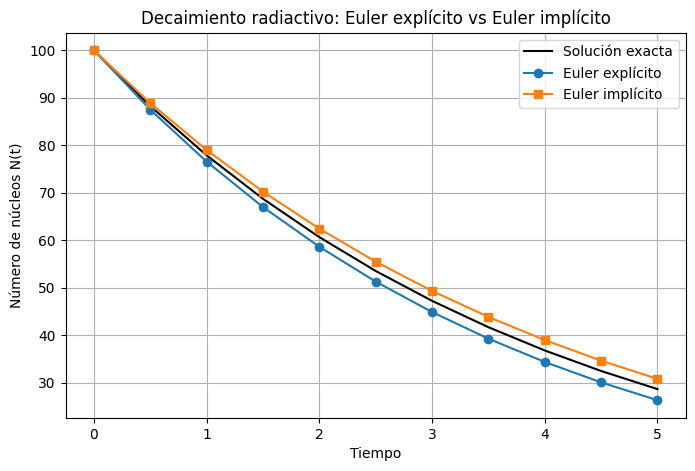

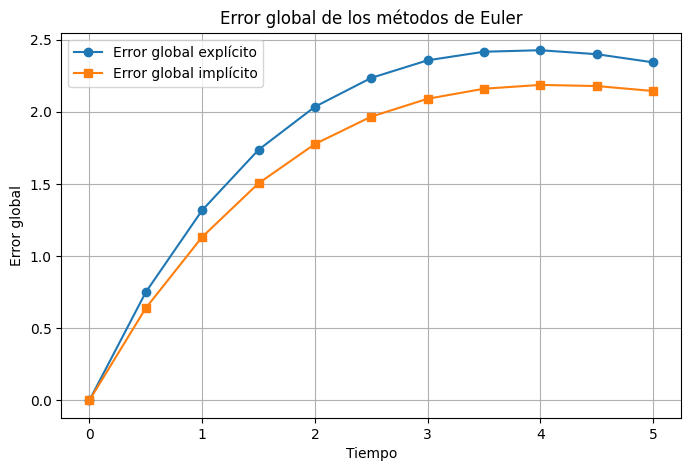

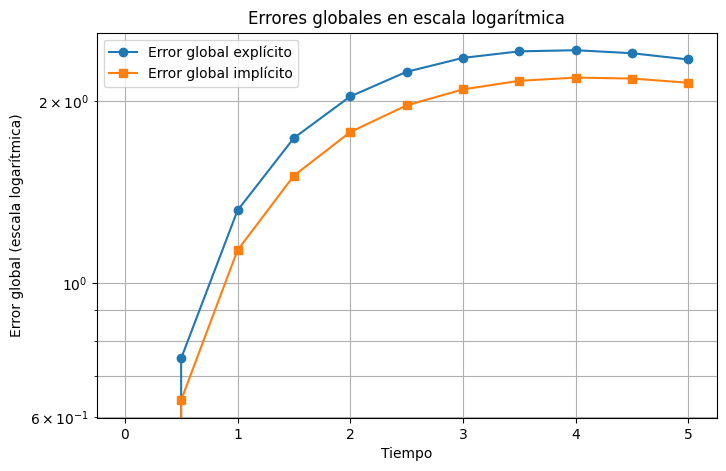

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(t_vals, N_exact, 'k-', label='Solución exacta')
plt.plot(t_vals, N_explicit, 'o-', label='Euler explícito')
plt.plot(t_vals, N_implicit, 's-', label='Euler implícito')
plt.xlabel('Tiempo')
plt.ylabel('Número de núcleos N(t)')
plt.title('Decaimiento radiactivo: Euler explícito vs Euler implícito')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_vals, global_error_explicit, 'o-', label='Error global explícito')
plt.plot(t_vals, global_error_implicit, 's-', label='Error global implícito')
plt.xlabel('Tiempo')
plt.ylabel('Error global')
plt.title('Error global de los métodos de Euler')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(t_vals, global_error_explicit, 'o-', label='Error global explícito')
plt.semilogy(t_vals, global_error_implicit, 's-', label='Error global implícito')
plt.xlabel('Tiempo')
plt.ylabel('Error global (escala logarítmica)')
plt.title('Errores globales en escala logarítmica')
plt.legend()
plt.grid(True, which='both')
plt.show()

## Estudio de convergencia

Comprobamos cómo cambia el error global en el tiempo final cuando disminuye el tamaño del paso $\Delta t$. Para un método de Euler, se espera una convergencia de orden 1, es decir, el error global debe decrecer proporcionalmente a $\Delta t$.


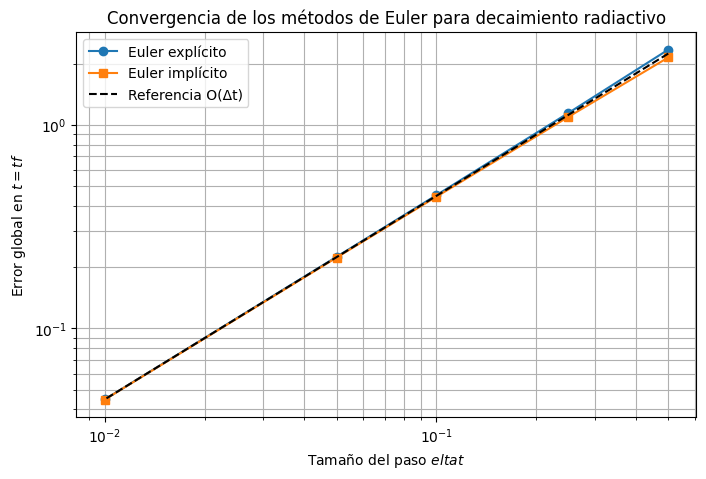

In [3]:
dt_values = [0.5, 0.25, 0.1, 0.05, 0.01]
errors_explicit = []
errors_implicit = []

for dt in dt_values:
    nt = int((tf - t0) / dt)
    t_temp = np.linspace(t0, tf, nt + 1)
    N_explicit_temp = np.zeros(nt + 1)
    N_implicit_temp = np.zeros(nt + 1)
    N_exact_temp = N0 * np.exp(-alpha * t_temp)
    N_explicit_temp[0] = N0
    N_implicit_temp[0] = N0
    for i in range(nt):
        N_explicit_temp[i + 1] = N_explicit_temp[i] - alpha * dt * N_explicit_temp[i]
        N_implicit_temp[i + 1] = N_implicit_temp[i] / (1 + alpha * dt)
    errors_explicit.append(abs(N_exact_temp[-1] - N_explicit_temp[-1]))
    errors_implicit.append(abs(N_exact_temp[-1] - N_implicit_temp[-1]))

plt.figure(figsize=(8, 5))
plt.loglog(dt_values, errors_explicit, 'o-', label='Euler explícito')
plt.loglog(dt_values, errors_implicit, 's-', label='Euler implícito')
ref = errors_explicit[-1] * (np.array(dt_values) / dt_values[-1])
plt.loglog(dt_values, ref, 'k--', label='Referencia O(Δt)')
plt.xlabel('Tamaño del paso $elta t$')
plt.ylabel('Error global en $t=tf$')
plt.title('Convergencia de los métodos de Euler para decaimiento radiactivo')
plt.legend()
plt.grid(True, which='both')
plt.show()